<a href="https://colab.research.google.com/github/ARNAV2-4DEV/minorProject2/blob/main/minorProject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Dataset Selection & Problem Definition

[cite_start]**Dataset Source:** https://www.kaggle.com/datasets/neuromusic/avocado-prices [cite: 92, 96]

### Data Dictionary
* [cite_start]**Date:** The date of the observation [cite: 97]
* [cite_start]**AveragePrice:** The average price of a single avocado [cite: 97]
* [cite_start]**Total Volume:** Total number of avocados sold [cite: 97]
* [cite_start]**Total Bags / Small Bags / Large Bags / XLarge Bags:** Total bags sold broken down by size [cite: 97]
* [cite_start]**type:** Conventional or organic [cite: 97]
* [cite_start]**region:** The city or region of the observation [cite: 97]

### Core Business Questions
1. [cite_start]How do avocado prices fluctuate dynamically across different seasonal periods? [cite: 98]
2. [cite_start]Does the volume of sales show an elastic economic response to price adjustments? [cite: 98]
3. [cite_start]What premium margin do organic variations command over conventional types across regional markets? [cite: 98]

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df.head(10)

Saving archive.zip to archive.zip


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
5,5,2015-11-22,1.26,55979.78,1184.27,48067.99,43.61,6683.91,6556.47,127.44,0.0,conventional,2015,Albany
6,6,2015-11-15,0.99,83453.76,1368.92,73672.72,93.26,8318.86,8196.81,122.05,0.0,conventional,2015,Albany
7,7,2015-11-08,0.98,109428.33,703.75,101815.36,80.00,6829.22,6266.85,562.37,0.0,conventional,2015,Albany
8,8,2015-11-01,1.02,99811.42,1022.15,87315.57,85.34,11388.36,11104.53,283.83,0.0,conventional,2015,Albany
9,9,2015-10-25,1.07,74338.76,842.40,64757.44,113.00,8625.92,8061.47,564.45,0.0,conventional,2015,Albany


In [4]:
df.info()

df['Date'] = pd.to_datetime(df['Date'])

print("Missing Values:")
print(df.isnull().sum())
df = df.dropna()

print("Duplicate Rows Found:", df.duplicated().sum())
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB
Missing Values:
Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0

Skewness Metrics:
AveragePrice    0.580303
Total Volume    9.007687
Total Bags      9.756072
Small Bags      9.540660
dtype: float64


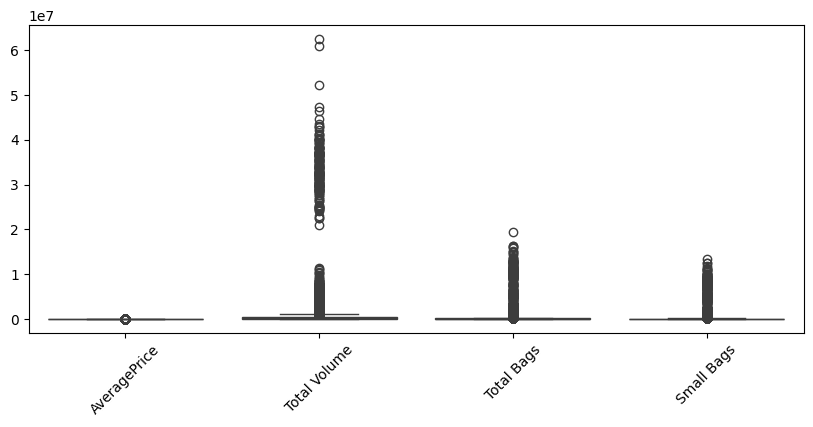

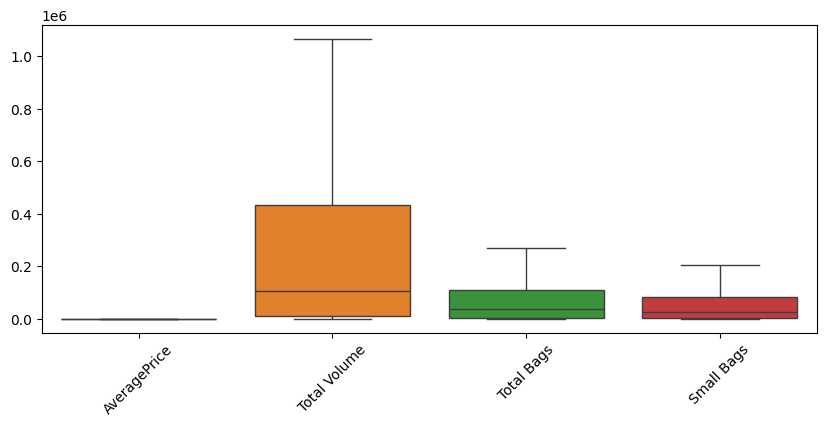

In [5]:
numeric_cols = ['AveragePrice', 'Total Volume', 'Total Bags', 'Small Bags']
print("Skewness Metrics:")
print(df[numeric_cols].skew())

plt.figure(figsize=(10, 4))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

plt.figure(figsize=(10, 4))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

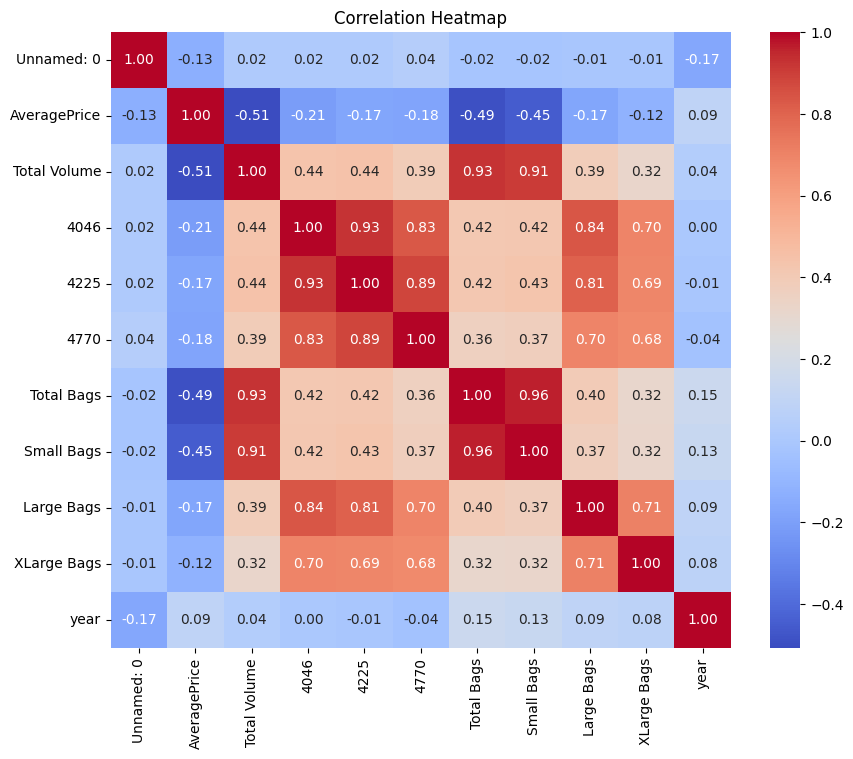

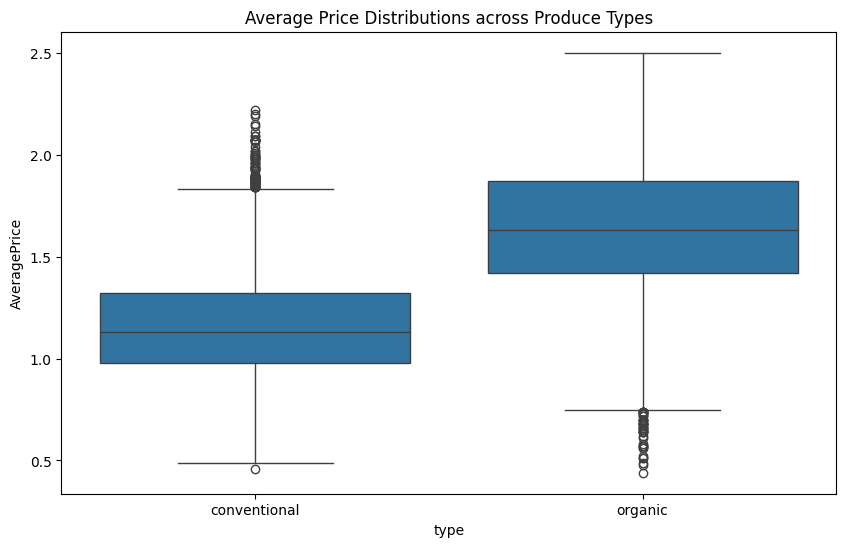

In [6]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='type', y='AveragePrice')
plt.title('Average Price Distributions across Produce Types')
plt.show()

In [7]:
df['Small_Bags_Ratio'] = (df['Small Bags'] / (df['Total Bags'] + 1e-5)) * 100

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

df = pd.get_dummies(df, columns=['region'], drop_first=True)

df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,...,False,False,False,False,False,False,False,False,False,False
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,...,False,False,False,False,False,False,False,False,False,False
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,...,False,False,False,False,False,False,False,False,False,False
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,...,False,False,False,False,False,False,False,False,False,False
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,...,False,False,False,False,False,False,False,False,False,False


### Summary Analysis & Interpretations

**Correlation vs. Causation Review:**
* [cite_start]A strong negative correlation exists between `AveragePrice` and `Total Volume`[cite: 119]. [cite_start]While this conforms heavily to supply-demand economic dynamics, it does not guarantee immediate direct causation; regional distribution bottlenecks or localized pricing spikes serve as hidden confounding variables driving simultaneous trend lines[cite: 121].

**Categorical Encoding Justification:**
* [cite_start]**Ordinal Fields:** The `type` variable possesses explicit binary rankings (Conventional vs. Organic), making it perfectly suited for structural Label Encoding mapping[cite: 125, 126].
* [cite_start]**Nominal Fields:** The geographic `region` indicator does not maintain implicit hierarchical ranking thresholds, requiring explicit One-Hot Dummy Expansion to maintain data mathematical parity[cite: 125, 126].

**Model-Ready Assessment:**
* The structured data asset is now fully optimized and model-ready. [cite_start]It features absolute containment of extreme outliers via targeted IQR bounds [cite: 106, 116][cite_start], mathematically parsed tracking vectors, zero duplicate row intersections [cite: 103][cite_start], and downstream categorical translation schemas compiled across all feature arrays[cite: 126].